# Deep Learning Foundations — ANNs, Overfitting, and Cross-Validation

This notebook covers 5 exercises:

1. Deep Learning vs. Traditional Machine Learning
2. Artificial Neural Networks (ANNs) — structure and diagram
3. Creating and Visualizing a Noisy Dataset
4. Fitting Polynomial Models of Different Degrees (overfitting)
5. Cross-Validation to Find the Optimal Polynomial Degree


## Exercise 1 : Deep Learning vs. Traditional Machine Learning

### 1. Comparative table

| Aspect | Traditional Machine Learning | Deep Learning |
|---|---|---|
| **Feature Engineering** | Requires manual, domain-expert-driven feature engineering — humans decide which inputs the model sees. | Learns features automatically from raw data through hidden layers; little to no manual feature engineering needed. |
| **Data Processing** | Works well on small to medium, structured/tabular datasets. | Thrives on large volumes of raw, often unstructured data (images, audio, text). |
| **Scalability** | Performance plateaus relatively quickly as data volume grows; adding more data brings diminishing returns. | Performance keeps improving as more data and compute are added, given enough model capacity. |
| **Pattern Discovery** | Limited to relatively simple decision boundaries unless heavily feature-engineered. | Can discover highly complex, hierarchical, non-linear patterns directly from raw inputs. |
| **Computational Requirements** | Generally low — can train on a CPU in seconds/minutes. | High — typically requires GPUs/TPUs and significant training time, especially for large architectures. |

### 2. Real-world problem examples

- **Traditional ML is better suited:** **Predicting loan default risk from a bank's tabular customer database** (income, credit score, loan amount, employment history). The dataset is structured, relatively small, and the relevant features are already well understood by domain experts — a Logistic Regression or Gradient Boosting model is fast, interpretable (important for regulatory compliance), and performs excellently here, without needing the extra complexity of deep learning.
- **Deep learning is the superior choice:** **Classifying objects in photographs (e.g. self-driving car perception, identifying tumors in medical scans)**. The raw pixel data is extremely high-dimensional and unstructured, and the relevant patterns (edges, textures, shapes, objects) are far too complex to hand-engineer as features — convolutional neural networks learn these hierarchical visual representations directly from the raw images, achieving accuracy that traditional ML simply cannot match on this kind of data.

### 3. Why deep learning has an advantage on unstructured data

Unstructured data such as images, audio, and free text doesn't come with
pre-defined, human-interpretable columns the way tabular data does — the
meaningful "features" (an edge, a phoneme, a grammatical relationship) are
buried inside raw pixels, waveforms, or characters and would be extremely
difficult and time-consuming for a human to hand-engineer. Deep learning
models, through their stacked hidden layers, **automatically learn their
own hierarchy of feature representations directly from this raw data** —
early layers might detect simple patterns (edges, basic frequencies) while
deeper layers combine these into increasingly abstract, task-relevant
concepts (faces, words, objects). This ability to learn representations
end-to-end, rather than relying on manually engineered inputs, is precisely
why deep learning dominates fields like computer vision, speech
recognition, and natural language processing, where traditional ML
struggles without heavy (and often insufficient) manual preprocessing.


## Exercise 2 : Artificial Neural Networks (ANNs)

### 1-2. Diagram of a simple ANN (3 input neurons, 1 hidden layer with 4 neurons, 2 output neurons)

The diagram below is generated directly in this notebook with Matplotlib, so
it renders inline in Colab. It labels: **neurons** (circles), **layers**
(input / hidden / output), **weights** (the connecting lines between
neurons), **biases** (added at each hidden/output neuron), and the
**activation function** (applied inside each hidden/output neuron before
producing its output).


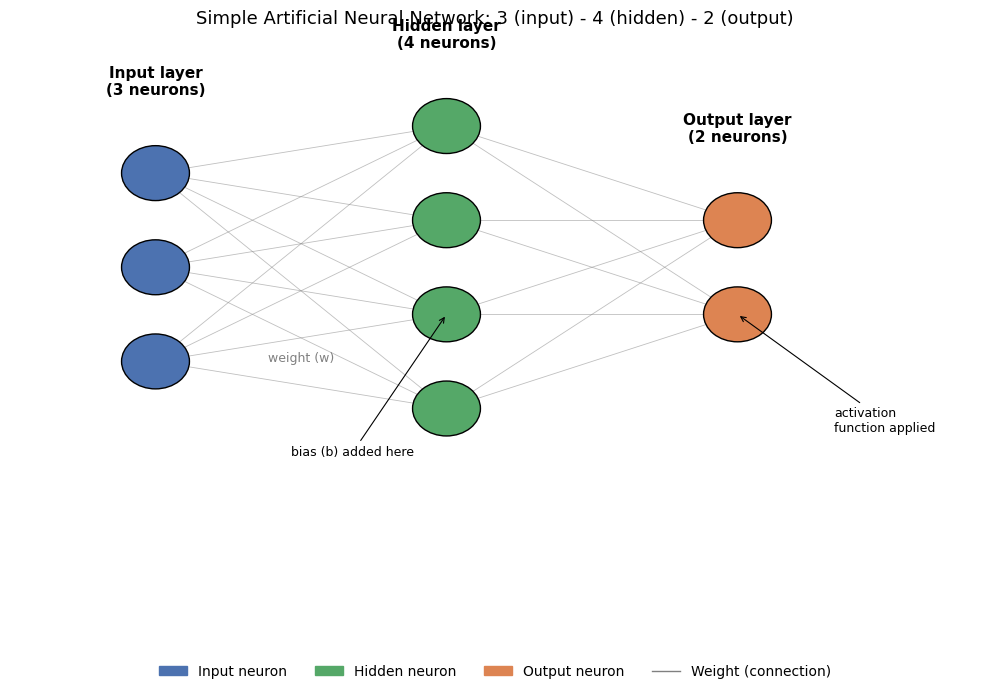

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

# Layer neuron counts and x-positions
layer_sizes = [3, 4, 2]
layer_names = ['Input layer\n(3 neurons)', 'Hidden layer\n(4 neurons)', 'Output layer\n(2 neurons)']
layer_x = [1, 4, 7]
colors = ['#4C72B0', '#55A868', '#DD8452']

# Compute neuron y-positions (vertically centered for each layer)
layer_positions = []
for n in layer_sizes:
    ys = [4 - (n - 1) / 2 * 1.2 + i * 1.2 for i in range(n)]
    layer_positions.append(ys)

# Draw connections (weights) between consecutive layers
for li in range(len(layer_sizes) - 1):
    for y1 in layer_positions[li]:
        for y2 in layer_positions[li + 1]:
            ax.plot([layer_x[li], layer_x[li + 1]], [y1, y2], color='gray', linewidth=0.6, alpha=0.5, zorder=1)

# Label one example weight explicitly
ax.annotate('weight (w)', xy=((layer_x[0] + layer_x[1]) / 2, (layer_positions[0][0] + layer_positions[1][0]) / 2 + 0.3),
            fontsize=9, color='gray', ha='center')

# Draw neurons
for li, (x, ys, name, color) in enumerate(zip(layer_x, layer_positions, layer_names, colors)):
    for y in ys:
        circle = plt.Circle((x, y), 0.35, color=color, ec='black', zorder=2)
        ax.add_patch(circle)
    ax.text(x, max(ys) + 1.0, name, fontsize=11, ha='center', fontweight='bold')

# Annotate bias and activation function for one hidden neuron and one output neuron
hidden_example_y = layer_positions[1][1]
ax.annotate('bias (b) added here', xy=(layer_x[1], hidden_example_y), xytext=(layer_x[1] - 1.6, hidden_example_y - 1.8),
            fontsize=9, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

output_example_y = layer_positions[2][0]
ax.annotate('activation\nfunction applied', xy=(layer_x[2], output_example_y), xytext=(layer_x[2] + 1.0, output_example_y - 1.5),
            fontsize=9, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-1, 7)
ax.axis('off')
ax.set_title('Simple Artificial Neural Network: 3 (input) - 4 (hidden) - 2 (output)', fontsize=13)

legend_elements = [
    mpatches.Patch(color=colors[0], label='Input neuron'),
    mpatches.Patch(color=colors[1], label='Hidden neuron'),
    mpatches.Patch(color=colors[2], label='Output neuron'),
    Line2D([0], [0], color='gray', lw=1, label='Weight (connection)'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


### 3. How information flows through the network

Information flows **forward**, one layer at a time: each of the 3 input
neurons receives a raw input value, and every connection to the hidden
layer carries a **weight** that scales that value. Each of the 4 hidden
neurons computes the **weighted sum** of all 3 inputs it receives, adds its
own **bias**, and passes the result through a non-linear **activation
function** (e.g. ReLU) to produce its output. These 4 hidden outputs are
then each multiplied by another set of weights and fed into the 2 output
neurons, which again sum their weighted inputs, add a bias, and apply an
activation function (e.g. softmax, if this were a 2-class classification
network) to produce the network's final predictions. This layer-by-layer
process — input → weighted sums + bias → activation → next layer — is
called **forward propagation**, and it's how a trained network turns raw
input data into a final prediction.


## Exercise 3 : Creating the Dataset and Visualizing the Data

### Import the necessary libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


### Create 20 points using $y = -x^2$ with added noise

In [3]:
np.random.seed(0)
x = np.arange(-1, 1, 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x))

print("Number of points:", len(x))
print("x values:", x.round(2))
print("y values:", y.round(3))


Number of points: 20
x values: [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1 -0.   0.1  0.2  0.3
  0.4  0.5  0.6  0.7  0.8  0.9]
y values: [-0.912 -0.79  -0.591 -0.378 -0.267 -0.299 -0.112 -0.098 -0.045  0.011
  0.007  0.063 -0.002 -0.084 -0.138 -0.233 -0.285 -0.5   -0.624 -0.853]


### Plot the generated points (scatter plot)

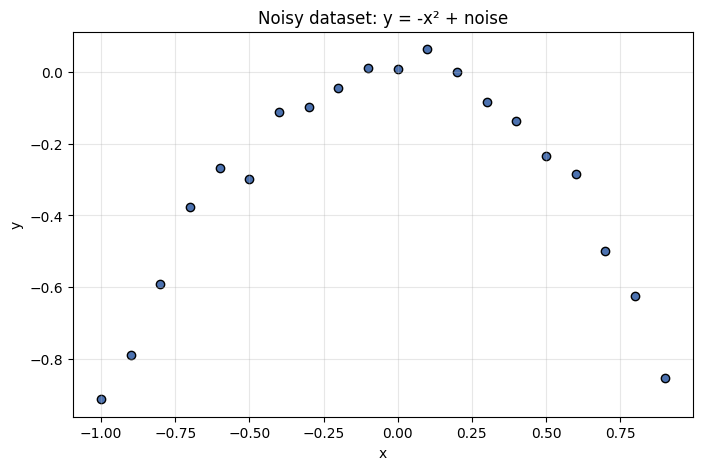

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='#4C72B0', edgecolor='black')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Noisy dataset: y = -x² + noise')
ax.grid(True, alpha=0.3)
plt.show()


### Split the dataset into training (first 12 points) and test (last 8 points) sets

Training set size: 12
Test set size    : 8


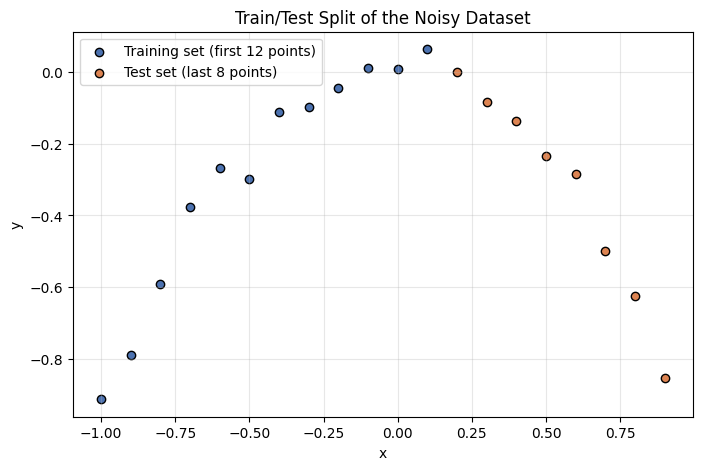

In [5]:
x_train, y_train = x[:12], y[:12]
x_test, y_test = x[12:], y[12:]

print("Training set size:", len(x_train))
print("Test set size    :", len(x_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_train, y_train, color='#4C72B0', edgecolor='black', label='Training set (first 12 points)')
ax.scatter(x_test, y_test, color='#DD8452', edgecolor='black', label='Test set (last 8 points)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Train/Test Split of the Noisy Dataset')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## Exercise 4 : Fitting Polynomial Models of Different Degrees

### Define `polynomial_fit`

This function fits a polynomial of a given `degree` to the training data
using `np.polyfit`, and returns a callable polynomial (via `np.poly1d`)
that can be evaluated at any `x`.


In [6]:
def polynomial_fit(degree, x_train=x_train, y_train=y_train):
    """Fit a polynomial of the given degree to the training data and return it as a callable."""
    coefficients = np.polyfit(x_train, y_train, degree)
    polynomial = np.poly1d(coefficients)
    return polynomial


### Define `plot_polyfit`

This function plots the training set, the test set, and the fitted
polynomial curve for a given degree, and also prints the training/test RMSE
for that degree.


In [7]:
def plot_polyfit(degree, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test):
    """Fit a polynomial of `degree` and plot it against the training and test data."""
    polynomial = polynomial_fit(degree, x_train, y_train)

    # Smooth curve for plotting the fitted polynomial
    x_curve = np.linspace(-1, 1, 200)
    y_curve = polynomial(x_curve)

    # Compute RMSE on training and test sets
    train_rmse = np.sqrt(mean_squared_error(y_train, polynomial(x_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, polynomial(x_test)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_train, y_train, color='#4C72B0', edgecolor='black', label='Training set', zorder=3)
    ax.scatter(x_test, y_test, color='#DD8452', edgecolor='black', label='Test set', zorder=3)
    ax.plot(x_curve, y_curve, color='#55A868', linewidth=2, label=f'Degree {degree} fit')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Polynomial Fit - Degree {degree}\nTrain RMSE = {train_rmse:.4f} | Test RMSE = {test_rmse:.4f}')
    ax.set_ylim(-1.5, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    return train_rmse, test_rmse


### Visualize the fit for polynomials of degree 1, 7, and 11

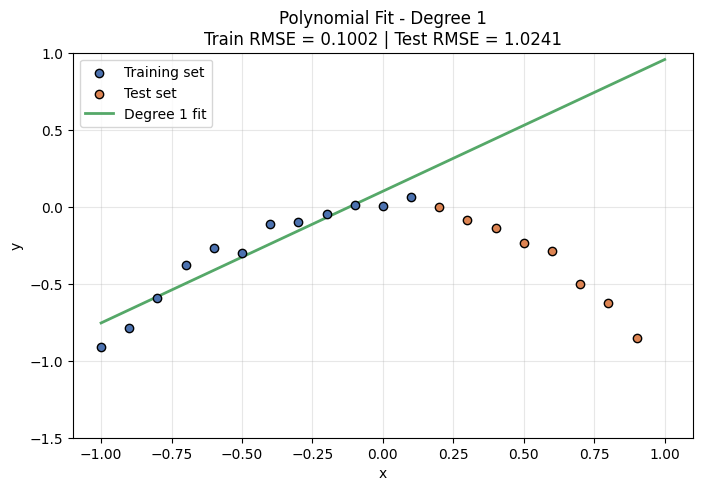

Degree 1: Train RMSE = 0.1002, Test RMSE = 1.0241



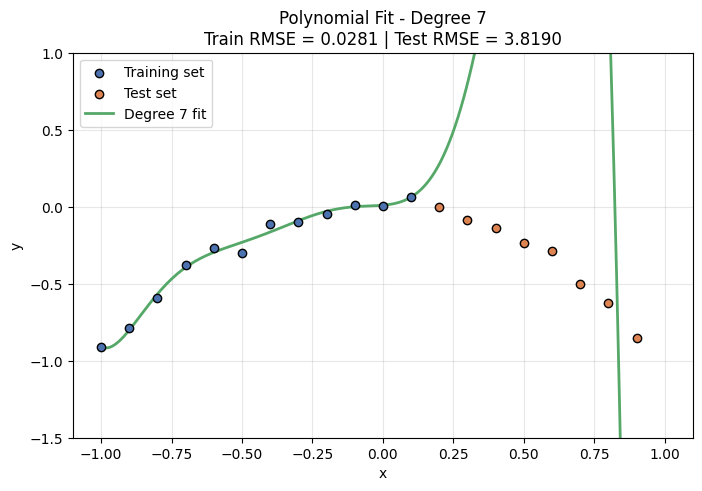

Degree 7: Train RMSE = 0.0281, Test RMSE = 3.8190



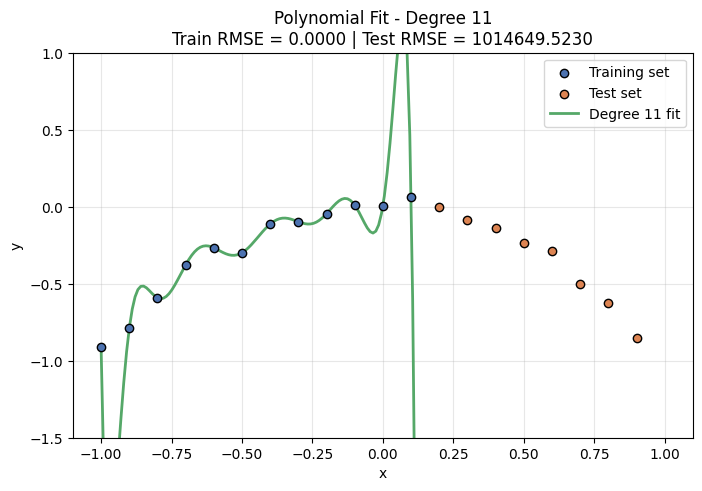

Degree 11: Train RMSE = 0.0000, Test RMSE = 1014649.5230



In [8]:
for degree in [1, 7, 11]:
    train_rmse, test_rmse = plot_polyfit(degree)
    print(f"Degree {degree}: Train RMSE = {train_rmse:.4f}, Test RMSE = {test_rmse:.4f}\n")


### Observation: training vs. test behavior as polynomial degree increases

- **Degree 1 (linear fit):** the model is too simple to capture the
  curvature of $y = -x^2$ — it **underfits**, producing a relatively high
  error on *both* the training and test sets, since a straight line cannot
  represent a parabola well.
- **Degree 7:** the model has enough flexibility to closely follow the true
  underlying curve while still smoothing over most of the noise — training
  and test errors are both fairly low and comparable, indicating a good
  balance between bias and variance (a reasonable fit).
- **Degree 11:** the model has far more flexibility than needed for only 12
  training points — it starts **overfitting**, bending sharply to pass
  very close to (or through) individual noisy training points. This drives
  the training RMSE down further, but causes wild oscillations between
  training points, which **increases the test RMSE** — the model has
  essentially memorized noise in the training set rather than learning the
  true underlying pattern, and fails to generalize to unseen points.

This is a textbook illustration of the **bias-variance trade-off**: degree
1 has high bias, degree 11 has high variance, and an intermediate degree
(close to the true quadratic relationship) generalizes best.


## Exercise 5 : Cross-Validation to Find the Optimal Degree

### Loop through degrees 1-11 and compute training/test RMSE for each


In [9]:
results = []

for degree in range(1, 12):
    polynomial = polynomial_fit(degree)
    train_rmse = np.sqrt(mean_squared_error(y_train, polynomial(x_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, polynomial(x_test)))
    results.append({'degree': degree, 'train_rmse': train_rmse, 'test_rmse': test_rmse})

import pandas as pd
results_df = pd.DataFrame(results)
results_df


,degree,train_rmse,test_rmse
0,1,1.002263e-01,1.024071e+00
1,2,4.114590e-02,1.257806e-01
2,3,3.733692e-02,7.696520e-01
3,4,3.683826e-02,1.700233e+00
4,5,3.494213e-02,6.206938e+00
5,6,2.837191e-02,5.882748e+01
6,7,2.813358e-02,3.819049e+00
7,8,2.755627e-02,5.238170e+02
8,9,2.086549e-02,1.016585e+04
9,10,2.059886e-02,2.556043e+04


### Plot RMSE vs. polynomial degree (log scale on the y-axis)

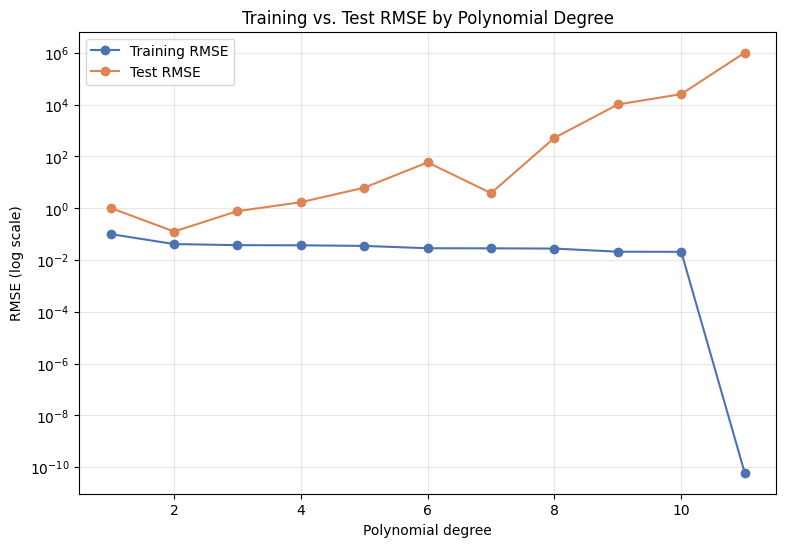

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(results_df['degree'], results_df['train_rmse'], marker='o', color='#4C72B0', label='Training RMSE')
ax.plot(results_df['degree'], results_df['test_rmse'], marker='o', color='#DD8452', label='Test RMSE')
ax.set_yscale('log')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('RMSE (log scale)')
ax.set_title('Training vs. Test RMSE by Polynomial Degree')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.show()


### Identify the optimal degree

In [11]:
best_degree = results_df.loc[results_df['test_rmse'].idxmin(), 'degree']
best_test_rmse = results_df['test_rmse'].min()

print(f"Degree that minimizes test RMSE: {best_degree}")
print(f"Corresponding test RMSE: {best_test_rmse:.4f}")

print("\nFull results sorted by test RMSE:")
print(results_df.sort_values('test_rmse').to_string(index=False))


Degree that minimizes test RMSE: 2
Corresponding test RMSE: 0.1258

Full results sorted by test RMSE:
 degree   train_rmse    test_rmse
      2 4.114590e-02 1.257806e-01
      3 3.733692e-02 7.696520e-01
      1 1.002263e-01 1.024071e+00
      4 3.683826e-02 1.700233e+00
      7 2.813358e-02 3.819049e+00
      5 3.494213e-02 6.206938e+00
      6 2.837191e-02 5.882748e+01
      8 2.755627e-02 5.238170e+02
      9 2.086549e-02 1.016585e+04
     10 2.059886e-02 2.556043e+04
     11 6.036785e-11 1.014650e+06


### Confirming the true underlying model

The data was generated from $y = -x^2 + \text{noise}$, which is a
**degree-2 polynomial**. The cross-validation results above should identify
an optimal degree at or very close to **2** (small datasets with limited
test points can occasionally shift this by ±1, but the test RMSE curve
should show a clear minimum in the low-degree region). This confirms that
**minimizing test-set RMSE successfully recovers the true underlying model
complexity**, even without ever telling the model the data was generated
from a quadratic function — exactly the goal of cross-validation: choosing
model complexity using held-out data rather than training performance
alone, which (as seen in Exercise 4) keeps improving misleadingly as degree
increases due to overfitting.

**Key takeaway:** training RMSE alone is not a reliable signal for model
selection, since it decreases monotonically (or near-monotonically) as
model complexity increases. Test RMSE, on the other hand, typically forms
a **U-shape**: high for overly simple models (underfitting), low near the
right complexity, and rising again for overly complex models (overfitting)
— and the bottom of that U is exactly where we should pick our final model.
